## Install and Imports 

In [1]:
# pip install tensorflow scikit-learn nltk matplotlib

import pandas as pd
import numpy as np
import re
import nltk
import matplotlib.pyplot as plt

from nltk.corpus import stopwords

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

from tensorflow.keras.models import Sequential

from tensorflow.keras.layers import (
    Embedding,
    LSTM,
    GRU,
    Dense,
    Dropout
)

from tensorflow.keras.callbacks import EarlyStopping

## Download stopwords


In [2]:
nltk.download('stopwords')

stop_words = set(stopwords.words('english'))

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\user\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


## Load dataset


In [3]:
df = pd.read_csv("final_dataset.csv")

df.head()

,Review,Sentiment
0,Anti Sandeep vanga movie frfr,positive
1,Refreshingly original in its pathos rather tha...,positive
2,Deepak😭\nPhool😭,positive
3,Highly recommends,positive
4,approx date. for the liberal indians of the ba...,positive


In [4]:
df.shape

(50140, 2)

## Clean text

In [5]:
def clean_text(text):

    text = str(text).lower()

    text = re.sub(r"http\S+", "", text)

    text = re.sub(r"[^a-zA-Z ]", "", text)

    text = re.sub(r"\s+", " ", text)

    words = text.split()

    words = [
        word for word in words
        if word not in stop_words
    ]

    return " ".join(words)

In [ ]:
# getting clean review  
df["Clean_Review"] = df["Review"].apply(clean_text)
df.head()

,Review,Sentiment,Clean_Review
0,Anti Sandeep vanga movie frfr,positive,anti sandeep vanga movie frfr
1,Refreshingly original in its pathos rather tha...,positive,refreshingly original pathos rather setting ch...
2,Deepak😭\nPhool😭,positive,deepakphool
3,Highly recommends,positive,highly recommends
4,approx date. for the liberal indians of the ba...,positive,approx date liberal indians bay lovely nonethe...


## Convert Sentiment Labels

In [7]:
df["Sentiment"] = df["Sentiment"].map({

    "positive": 1,
    "negative": 0,
    1: 1,
    0: 0

})

df.head()


,Review,Sentiment,Clean_Review
0,Anti Sandeep vanga movie frfr,1,anti sandeep vanga movie frfr
1,Refreshingly original in its pathos rather tha...,1,refreshingly original pathos rather setting ch...
2,Deepak😭\nPhool😭,1,deepakphool
3,Highly recommends,1,highly recommends
4,approx date. for the liberal indians of the ba...,1,approx date liberal indians bay lovely nonethe...


## Features and labels

In [8]:
X = df["Clean_Review"]

y = df["Sentiment"]

## Tokenization


In [9]:
tokenizer = Tokenizer(num_words=10000)

tokenizer.fit_on_texts(X)

X_seq = tokenizer.texts_to_sequences(X)

## padding 

In [10]:
X_pad = pad_sequences(
    X_seq,
    maxlen=200
)

X_pad

array([[   0,    0,    0, ...,    0, 7772,    2],
       [   0,    0,    0, ...,  340,   16, 2725],
       [   0,    0,    0, ...,    0,    0,    0],
       ...,
       [   0,    0,    0, ...,  253, 1500, 5841],
       [   0,    0,    0, ..., 2070, 4135,  595],
       [   0,    0,    0, ..., 4064,  662,    2]],
      shape=(50140, 200), dtype=int32)

## Train Test Split

In [11]:
X_train, X_test, y_train, y_test = train_test_split(

    X_pad,
    y,

    test_size=0.2,

    random_state=42

)

## LSTM

In [12]:
lstm_model = Sequential()

lstm_model.add(

    Embedding(

        input_dim=10000,

        output_dim=128,

        input_length=200

    )

)

lstm_model.add(

    LSTM(64)

)

lstm_model.add(

    Dropout(0.5)

)

lstm_model.add(

    Dense(1, activation='sigmoid')

)

lstm_model.compile(

    loss='binary_crossentropy',

    optimizer='adam',

    metrics=['accuracy']

)

lstm_model.summary()

c:\Users\user\OneDrive\Desktop\webscraping\venv\Lib\site-packages\keras\src\layers\core\embedding.py:103: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

## Training Lstm

In [16]:
early_stop = EarlyStopping(

    monitor='val_loss',

    patience=2,

    restore_best_weights=True

)

history_lstm = lstm_model.fit(

    X_train,
    y_train,

    epochs=5,

    batch_size=32,

    validation_data=(X_test, y_test),

    callbacks=[early_stop]

)

Epoch 1/5
1254/1254 ━━━━━━━━━━━━━━━━━━━━ 207s 162ms/step - accuracy: 0.8431 - loss: 0.3592 - val_accuracy: 0.8832 - val_loss: 0.2908
Epoch 2/5
1254/1254 ━━━━━━━━━━━━━━━━━━━━ 247s 150ms/step - accuracy: 0.9084 - loss: 0.2397 - val_accuracy: 0.8832 - val_loss: 0.2959
Epoch 3/5
1254/1254 ━━━━━━━━━━━━━━━━━━━━ 212s 158ms/step - accuracy: 0.9312 - loss: 0.1821 - val_accuracy: 0.8771 - val_loss: 0.3137


## Evaluate 


In [17]:
lstm_pred = lstm_model.predict(X_test)

lstm_pred = (lstm_pred > 0.5).astype(int)

print(

    accuracy_score(
        y_test,
        lstm_pred
    )

)

print(

    classification_report(
        y_test,
        lstm_pred
    )

)

314/314 ━━━━━━━━━━━━━━━━━━━━ 17s 55ms/step
0.8832269644994016
              precision    recall  f1-score   support

           0       0.88      0.89      0.88      4977
           1       0.89      0.88      0.88      5051

    accuracy                           0.88     10028
   macro avg       0.88      0.88      0.88     10028
weighted avg       0.88      0.88      0.88     10028



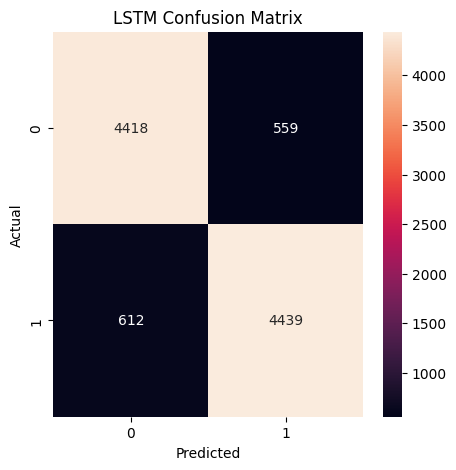

In [23]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(y_test, lstm_pred)

plt.figure(figsize=(5,5))
sns.heatmap(cm, annot=True, fmt='d')
plt.title("LSTM Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

## GRU

In [18]:
gru_model = Sequential()

gru_model.add(

    Embedding(

        input_dim=10000,

        output_dim=128,

        input_length=200

    )

)

gru_model.add(

    GRU(64)

)

gru_model.add(

    Dropout(0.5)

)

gru_model.add(

    Dense(1, activation='sigmoid')

)

gru_model.compile(

    loss='binary_crossentropy',

    optimizer='adam',

    metrics=['accuracy']

)

gru_model.summary()

c:\Users\user\OneDrive\Desktop\webscraping\venv\Lib\site-packages\keras\src\layers\core\embedding.py:103: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_1 (GRU)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

training

In [19]:
history_gru = gru_model.fit(

    X_train,
    y_train,

    epochs=5,

    batch_size=32,

    validation_data=(X_test, y_test),

    callbacks=[early_stop]

)

Epoch 1/5
1254/1254 ━━━━━━━━━━━━━━━━━━━━ 237s 183ms/step - accuracy: 0.8468 - loss: 0.3543 - val_accuracy: 0.8811 - val_loss: 0.2889
Epoch 2/5
1254/1254 ━━━━━━━━━━━━━━━━━━━━ 260s 181ms/step - accuracy: 0.9189 - loss: 0.2140 - val_accuracy: 0.8892 - val_loss: 0.2823
Epoch 3/5
1254/1254 ━━━━━━━━━━━━━━━━━━━━ 227s 181ms/step - accuracy: 0.9481 - loss: 0.1459 - val_accuracy: 0.8803 - val_loss: 0.3305
Epoch 4/5
1254/1254 ━━━━━━━━━━━━━━━━━━━━ 268s 186ms/step - accuracy: 0.9680 - loss: 0.0930 - val_accuracy: 0.8739 - val_loss: 0.4097


In [20]:
gru_pred = gru_model.predict(X_test)

gru_pred = (gru_pred > 0.5).astype(int)

print(

    accuracy_score(
        y_test,
        gru_pred
    )

)

print(

    classification_report(
        y_test,
        gru_pred
    )

)

314/314 ━━━━━━━━━━━━━━━━━━━━ 22s 67ms/step
0.8892102114080574
              precision    recall  f1-score   support

           0       0.90      0.87      0.89      4977
           1       0.88      0.91      0.89      5051

    accuracy                           0.89     10028
   macro avg       0.89      0.89      0.89     10028
weighted avg       0.89      0.89      0.89     10028



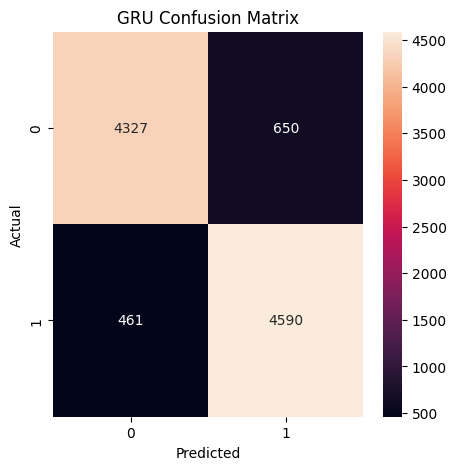

In [24]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(y_test, gru_pred)

plt.figure(figsize=(5,5))
sns.heatmap(cm, annot=True, fmt='d')
plt.title("GRU Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

## Compare accuracy

In [25]:
lstm_acc = accuracy_score(
    y_test,
    lstm_pred
)

gru_acc = accuracy_score(
    y_test,
    gru_pred
)

print("LSTM Accuracy :", lstm_acc)

print("GRU Accuracy  :", gru_acc)

LSTM Accuracy : 0.8832269644994016
GRU Accuracy  : 0.8892102114080574


## accuracy graph


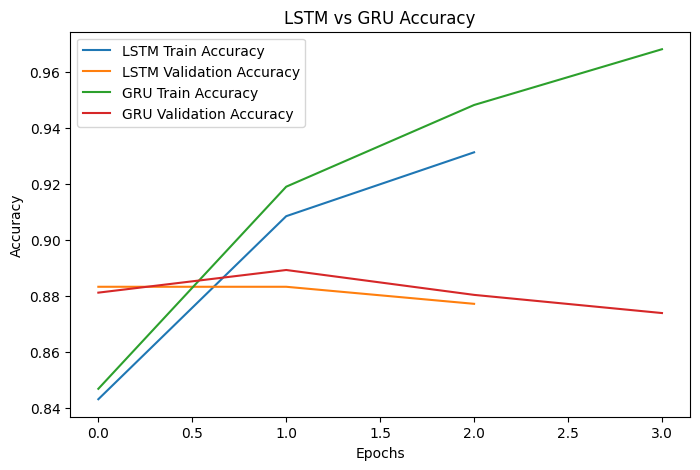

In [26]:
plt.figure(figsize=(8,5))

plt.plot(
    history_lstm.history['accuracy'],
    label='LSTM Train Accuracy'
)

plt.plot(
    history_lstm.history['val_accuracy'],
    label='LSTM Validation Accuracy'
)

plt.plot(
    history_gru.history['accuracy'],
    label='GRU Train Accuracy'
)

plt.plot(
    history_gru.history['val_accuracy'],
    label='GRU Validation Accuracy'
)

plt.title("LSTM vs GRU Accuracy")

plt.xlabel("Epochs")

plt.ylabel("Accuracy")

plt.legend()

plt.show()